In [1]:
import os
import torch

# Make only GPU 0 visible
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# After setting environment variable, import torch and select device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("Available GPUs:", torch.cuda.device_count())
    print("Current device ID:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
else:
    print("CUDA not available, using CPU.")



from sklearn.model_selection import train_test_split
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

Using device: cuda:0
GPU Name: NVIDIA A100-PCIE-40GB
Available GPUs: 1
Current device ID: 0
Device name: NVIDIA A100-PCIE-40GB


In [2]:
df = pd.read_csv("ESM2_embeddings_training.csv")
df.head()

,0,1,2,3,4,5,6,7,8,9,...,1271,1272,1273,1274,1275,1276,1277,1278,1279,Target
0,-0.063428,0.057937,-0.168569,-0.008432,0.172565,0.038662,-0.089021,-0.141282,-0.089521,-0.164691,...,-0.115826,0.002200,0.024835,0.089274,-0.117533,0.100819,-0.022806,-0.006047,-0.190084,1
1,-0.095857,0.000992,-0.129885,0.122867,0.077960,-0.025903,-0.056007,0.209455,-0.184158,-0.082347,...,-0.130541,-0.024977,0.042727,0.103795,0.021408,0.100512,-0.090890,0.123463,-0.092240,1
2,0.064072,0.000937,-0.033080,0.099279,-0.011478,-0.081602,-0.216677,0.453887,-0.131127,-0.026428,...,-0.056179,0.014935,0.042948,0.121292,0.018406,0.107305,0.049323,0.080158,-0.038722,1
3,-0.029309,-0.021870,-0.106842,0.041427,0.062836,0.078496,-0.005187,0.029256,0.020725,-0.046132,...,-0.081265,-0.044660,0.081675,0.012917,0.051705,0.050603,0.017290,-0.033859,-0.020603,1
4,0.043890,-0.050122,-0.069223,0.056650,0.093694,0.000708,-0.058652,-0.018942,-0.041816,0.003895,...,-0.162030,-0.039222,0.042716,0.083667,-0.033393,0.027137,0.003431,-0.017532,-0.017283,1


In [3]:
df.shape

(707, 1281)

In [4]:
X = df.drop("Target",axis=1)
y = df["Target"]
X,y

(            0         1         2         3         4         5         6  \
 0   -0.063428  0.057937 -0.168569 -0.008432  0.172565  0.038662 -0.089021   
 1   -0.095857  0.000992 -0.129885  0.122867  0.077960 -0.025903 -0.056007   
 2    0.064072  0.000937 -0.033080  0.099279 -0.011478 -0.081602 -0.216677   
 3   -0.029309 -0.021870 -0.106842  0.041427  0.062836  0.078496 -0.005187   
 4    0.043890 -0.050122 -0.069223  0.056650  0.093694  0.000708 -0.058652   
 ..        ...       ...       ...       ...       ...       ...       ...   
 702  0.024352 -0.009124  0.102097  0.040049  0.025363  0.010723 -0.079363   
 703 -0.024684  0.033187 -0.009253  0.020599 -0.000124  0.001507 -0.053862   
 704  0.005918 -0.056784 -0.008504  0.004717  0.001831  0.003036  0.046104   
 705  0.003824  0.010533  0.060692  0.101192  0.015688 -0.032066 -0.113197   
 706  0.029275  0.003985  0.000701  0.066429 -0.022957  0.024420 -0.035449   
 
             7         8         9  ...      1270      1271   

In [5]:
import numpy as np
X_train = np.array(X)
y_train = np.array(y)
y_train

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [6]:
X_train.shape

(707, 1280)

In [7]:
df_test = pd.read_csv("ESM2_embeddings_testing.csv")

X_test = np.array(df_test.drop("Target",axis=1))
y_test = np.array( df_test["Target"])

In [8]:
X_test,y_test

(array([[-0.00394924,  0.02155012,  0.04836239, ..., -0.21737432,
          0.12512141, -0.11359131],
        [ 0.04881484, -0.04572118, -0.04640543, ...,  0.07844282,
         -0.05925238, -0.0170291 ],
        [ 0.01137813, -0.01820512, -0.05086906, ...,  0.07079091,
         -0.02425195,  0.01250536],
        ...,
        [-0.01140917, -0.04694867,  0.04794169, ...,  0.06438019,
          0.07843079, -0.0021446 ],
        [ 0.03565512, -0.15795626,  0.011696  , ..., -0.23781578,
         -0.00353348,  0.11060435],
        [ 0.04018865,  0.05475337,  0.02423608, ...,  0.03382625,
         -0.07705455, -0.01826583]], shape=(178, 1280)),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [9]:

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    matthews_corrcoef, roc_auc_score, roc_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

import matplotlib.pyplot as plt


# ================================
# 2️⃣ Torch MLP Classifier
# ================================
class TorchMLPClassifier(BaseEstimator, ClassifierMixin):

    def __init__(self,
                 input_dim,
                 num_classes=2,
                 hidden_dim=128,
                 num_layers=2,
                 activation='relu',
                 dropout=0.1,
                 batch_norm=False,
                 optimizer='adam',
                 lr=1e-3,
                 weight_decay=0,
                 batch_size=32,
                 epochs=30,
                 device=None):

        self.input_dim = input_dim
        self.num_classes = num_classes
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.activation = activation
        self.dropout = dropout
        self.batch_norm = batch_norm
        self.optimizer = optimizer
        self.lr = lr
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.epochs = epochs
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        self.model = None

    def _get_activation(self):
        if self.activation == 'relu':
            return nn.ReLU()
        elif self.activation == 'gelu':
            return nn.GELU()
        elif self.activation == 'leaky_relu':
            return nn.LeakyReLU()
        else:
            raise ValueError("Unsupported activation")

    def _build_model(self):
        layers = []
        in_dim = self.input_dim

        for _ in range(self.num_layers):
            layers.append(nn.Linear(in_dim, self.hidden_dim))

            if self.batch_norm:
                layers.append(nn.BatchNorm1d(self.hidden_dim))

            layers.append(self._get_activation())
            layers.append(nn.Dropout(self.dropout))
            in_dim = self.hidden_dim

        layers.append(nn.Linear(in_dim, self.num_classes))

        return nn.Sequential(*layers)

    def fit(self, X, y):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.long)

        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset,
                            batch_size=self.batch_size,
                            shuffle=True)

        self.model = self._build_model().to(self.device)

        criterion = nn.CrossEntropyLoss()

        if self.optimizer == 'adam':
            optimizer = optim.Adam(self.model.parameters(),
                                   lr=self.lr,
                                   weight_decay=self.weight_decay)
        elif self.optimizer == 'adamw':
            optimizer = optim.AdamW(self.model.parameters(),
                                    lr=self.lr,
                                    weight_decay=self.weight_decay)
        else:
            optimizer = optim.RMSprop(self.model.parameters(),
                                      lr=self.lr,
                                      weight_decay=self.weight_decay)

        self.model.train()

        for _ in range(self.epochs):
            for xb, yb in loader:
                xb = xb.to(self.device)
                yb = yb.to(self.device)

                optimizer.zero_grad()
                outputs = self.model(xb)
                loss = criterion(outputs, yb)
                loss.backward()
                optimizer.step()

        return self

    def predict_proba(self, X):
        self.model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)

        with torch.no_grad():
            outputs = self.model(X_tensor)
            probs = torch.softmax(outputs, dim=1)

        return probs.cpu().numpy()

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)


# ================================
# Model + Hyperparameter Grid
# ================================
models_to_run = {
    'MLP': {
        'model': TorchMLPClassifier(
            input_dim=X_train.shape[1],
            num_classes=len(np.unique(y_train))
        ),
        'params': {
            "hidden_dim": [128, 256],
            "num_layers": [2, 3,4],
            "activation": ["relu", "gelu"],
            "batch_norm": [True, False],
            "dropout": [0.1, 0.3],
            "optimizer": ["adam", "adamw"],
            "lr": [1e-3, 1e-4],
            "weight_decay": [0, 1e-4],
            "batch_size": [16, 32],
            "epochs": [15,30, 50, 100]
        }
    }
}


# ================================
# 4️⃣ Evaluation Loop
# ================================
for name, config in models_to_run.items():

    print(f"\n--- Running {name} ---")
    print("Starting hyperparameter tuning...")

    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        scoring='roc_auc',
        cv=10,
        n_jobs=1 
    )

    grid_search.fit(np.array(X_train), np.array(y_train))
    best_model = grid_search.best_estimator_

    print("Best hyperparameters:")
    print(grid_search.best_params_)

    y_pred_proba = best_model.predict_proba(np.array(X_test))[:, 1]

    # ================================
    # 🔬 IMPORTANT SCIENTIFIC NOTE:
    # Reporting only Accuracy or AUC is NOT sufficient.
    # Calibration and optimal threshold must be defined.
    # ================================

    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    j_scores = tpr - fpr
    best_threshold = thresholds[np.argmax(j_scores)]
    print(f"Optimal threshold (Youden's J): {best_threshold:.4f}")

    y_pred = (y_pred_proba >= best_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    accuracy = accuracy_score(y_test, y_pred)
    specificity = tn / (tn + fp)
    report = classification_report(y_test, y_pred, output_dict=True)
    precision = report['1']['precision']
    sensitivity = report['1']['recall']
    f1 = report['1']['f1-score']
    mcc = matthews_corrcoef(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    brier = brier_score_loss(y_test, y_pred_proba)

    print("\n--- Evaluation Metrics ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {sensitivity:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print(f"AUC: {auc:.4f}")
    print(f"Brier Score: {brier:.4f}")


--- Running MLP ---
Starting hyperparameter tuning...
Best hyperparameters:
{'activation': 'relu', 'batch_norm': True, 'batch_size': 16, 'dropout': 0.1, 'epochs': 15, 'hidden_dim': 128, 'lr': 0.001, 'num_layers': 2, 'optimizer': 'adam', 'weight_decay': 0}
Optimal threshold (Youden's J): 0.6400

--- Evaluation Metrics ---
Accuracy: 0.9157
Specificity: 0.9402
Precision: 0.8833
Recall: 0.8689
F1 Score: 0.8760
MCC: 0.8123
AUC: 0.9320
Brier Score: 0.0767


In [10]:
best_model = grid_search.best_estimator_
print(best_model)

TorchMLPClassifier(batch_norm=True, batch_size=16, device='cuda', epochs=15,
                   input_dim=1280)


In [11]:
import pickle

with open("mlp_ESM2_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [12]:

import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    matthews_corrcoef, roc_auc_score, roc_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve


# ==========================================
#Load Model
# ==========================================
with open("mlp_ESM2_model.pkl", "rb") as f:
    model = pickle.load(f)

print("Model loaded successfully.")
print("Expected input dimension:", model.input_dim)


# ==========================================
#  Load Your Test Data
# ==========================================

X_test = np.array(X_test)
y_test = np.array(y_test)  # If labels exist

print("Test shape:", X_test.shape)


# ==========================================
#  Make Predictions
# ==========================================
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Use stored threshold
threshold = 0.6552
y_pred = (y_pred_proba >= threshold).astype(int)


# ==========================================
#  Evaluation Metrics
# ==========================================
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
specificity = tn / (tn + fp)
report = classification_report(y_test, y_pred, output_dict=True)
precision = report['1']['precision']
sensitivity = report['1']['recall']
f1 = report['1']['f1-score']
mcc = matthews_corrcoef(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
brier = brier_score_loss(y_test, y_pred_proba)

print("\n--- Test Performance ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {sensitivity:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Brier Score: {brier:.4f}")


Model loaded successfully.
Expected input dimension: 1280
Test shape: (178, 1280)

--- Test Performance ---
Accuracy: 0.9101
Specificity: 0.9402
Precision: 0.8814
Recall: 0.8525
F1 Score: 0.8667
MCC: 0.7992
AUC: 0.9320
Brier Score: 0.0767


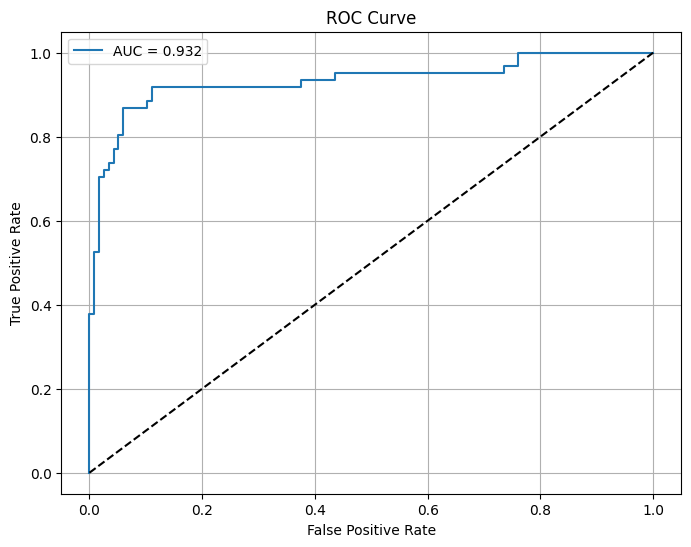

In [13]:

# ==========================================
#  ROC Curve (Save TIFF 600 DPI)
# ==========================================
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)

plt.savefig("ESM2_test_ROC_curve.tiff", dpi=600, format="tiff")
plt.show()
plt.close()

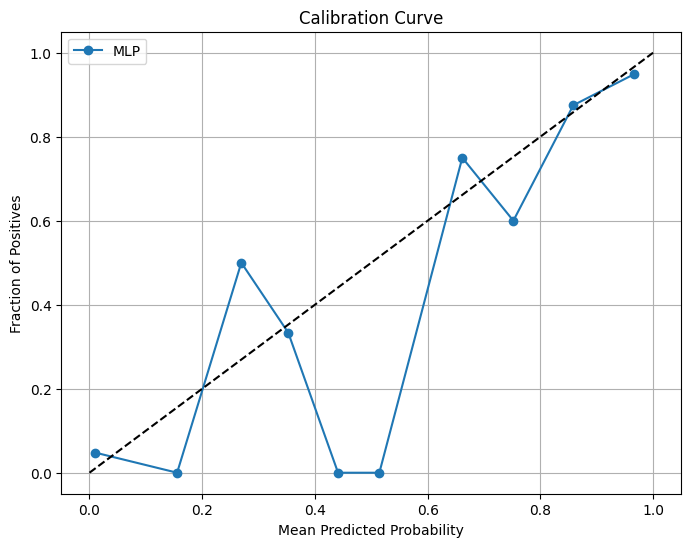

In [14]:

# ==========================================
#  Calibration Curve
# ==========================================
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='MLP')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)

plt.savefig("ESM2_test_calibration_curve.tiff", dpi=600, format="tiff")
plt.show()
plt.close()


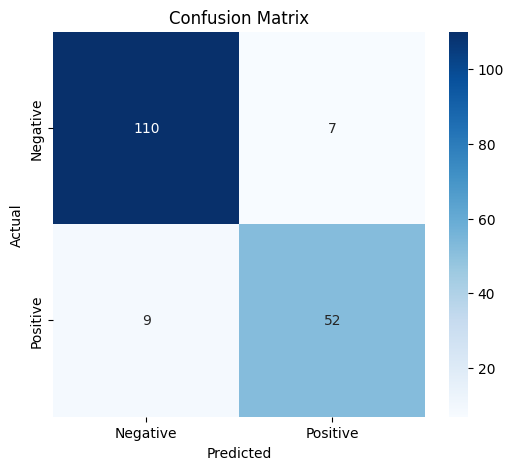

In [15]:

# ==========================================
#  Confusion Matrix
# ==========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.savefig("ESM2_test_confusion_matrix.tiff", dpi=600, format="tiff")
plt.show()
plt.close()


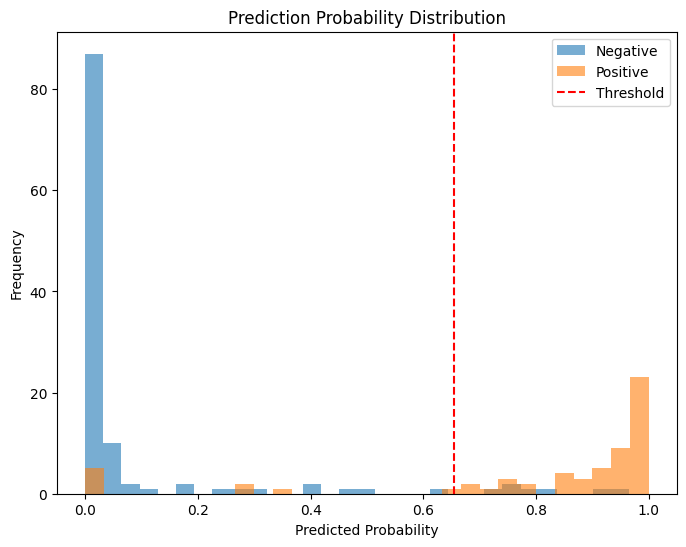

In [16]:

# ==========================================
#  Probability Distribution
# ==========================================
plt.figure(figsize=(8, 6))
plt.hist(y_pred_proba[y_test == 0], bins=30, alpha=0.6, label='Negative')
plt.hist(y_pred_proba[y_test == 1], bins=30, alpha=0.6, label='Positive')
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')

plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Prediction Probability Distribution')
plt.legend()

plt.savefig("ESM2_test_probability_distribution.tiff", dpi=600, format="tiff")
plt.show()
plt.close()


In [17]:
# ==========================================
#  Save Metrics to CSV
# ==========================================

metrics_dict = {
    "Metric": [
        "Accuracy",
        "Specificity",
        "Precision",
        "Recall",
        "F1 Score",
        "MCC",
        "AUC",
        "Brier Score"
    ],
    "Value": [
        accuracy,
        specificity,
        precision,
        sensitivity,
        f1,
        mcc,
        auc,
        brier
    ]
}

metrics_df = pd.DataFrame(metrics_dict)

metrics_df.to_csv("ESM2_test_metrics.csv", index=False)
print(metrics_df)
print("\nMetrics saved to ESM2_test_metrics.csv")

        Metric     Value
0     Accuracy  0.910112
1  Specificity  0.940171
2    Precision  0.881356
3       Recall  0.852459
4     F1 Score  0.866667
5          MCC  0.799151
6          AUC  0.932044
7  Brier Score  0.076740

Metrics saved to ESM2_test_metrics.csv


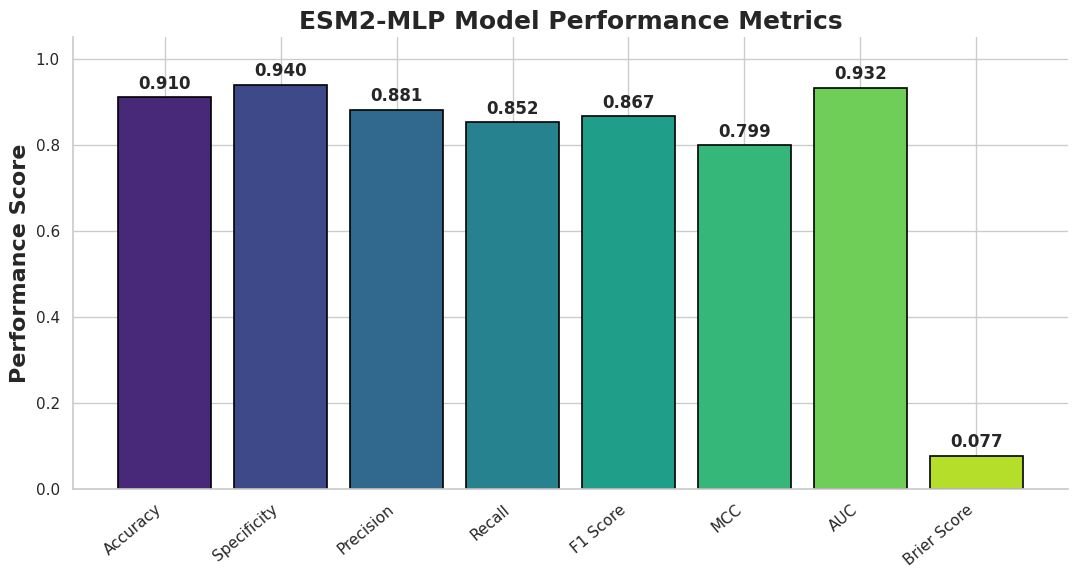

Colorful bar plot saved as ESM2_test_metrics_colorful_barplot.tiff


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set elegant theme
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": 14,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold"
})

# Custom vibrant but professional color palette
colors = sns.color_palette("viridis", len(metrics_df))

plt.figure(figsize=(11, 6))

bars = plt.bar(
    metrics_df["Metric"],
    metrics_df["Value"],
    color=colors,
    edgecolor='black',
    linewidth=1.2
)

plt.ylim(0, 1.05)
plt.xticks(rotation=40, ha='right')
plt.ylabel("Performance Score", fontsize=16)
plt.title("ESM2-MLP Model Performance Metrics", fontsize=18, weight='bold')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.3f}",
        ha='center',
        fontsize=12,
        weight='bold'
    )

# Remove top/right borders
sns.despine()

plt.tight_layout()

plt.savefig("ESM2_test_metrics_colorful_barplot.tiff",
            dpi=600,
            format="tiff")

plt.show()

print("Colorful bar plot saved as ESM2_test_metrics_colorful_barplot.tiff")

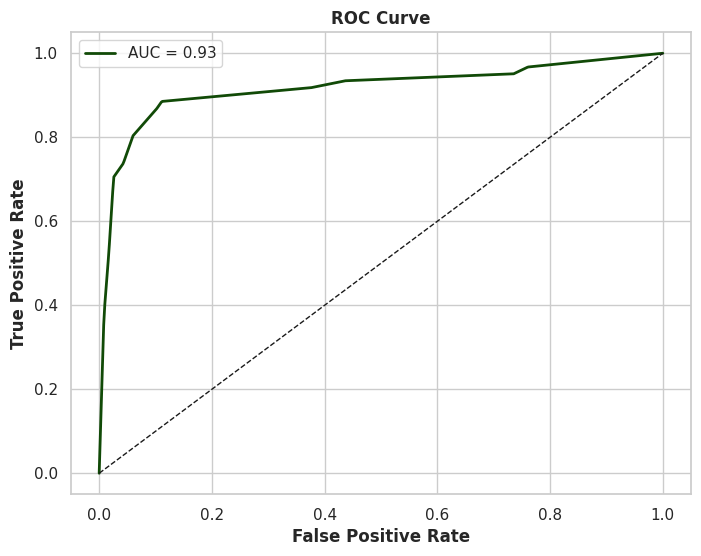

In [19]:
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

# Compute ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

# Remove duplicate FPR values (important for smoothing)
fpr_unique, idx = np.unique(fpr, return_index=True)
tpr_unique = tpr[idx]

# Create smooth grid
fpr_smooth = np.linspace(0, 1, 500)
tpr_smooth = np.interp(fpr_smooth, fpr_unique, tpr_unique)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(fpr_smooth, tpr_smooth,
         linewidth=2,
         color="#114A07",
         label=f'AUC = {auc:.2f}')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.savefig("ESM2_test_ROC_curve_smoothen.tiff", dpi=600, format="tiff")
plt.show()
plt.close()